# Short-Term Traffic Demand Forecasting

This research notebook develops and evaluates short-term traffic demand forecasting models for the University of Niagara Falls capstone project. The forecasting stage extends the earlier descriptive and operational analysis pipeline toward predictive modeling so that later stages can use next-hour traffic demand estimates for baseline signal timing evaluation, optimization, and simulation.


## 1. Project Context

This capstone project studies historical City of Toronto traffic data to support signal timing analysis and optimization. The earlier notebooks established the processed demand dataset, engineered signal-related predictors, and created baseline traffic control metrics. The present notebook focuses on **forecasting next-hour traffic demand**, which provides the predictive input required for later decision-support stages.


## 2. Forecasting Pipeline Overview

The notebook follows a clear forecasting workflow:

- load the engineered signal-optimization dataset;
- define the next-hour prediction target;
- construct temporal, cyclical, lag, and rolling-demand features;
- apply a chronological 2015-2018 / 2019 split;
- evaluate a Random Forest baseline and three sequence-based deep learning models;
- compare results visually and export reusable forecast artifacts.

This structure is intended to make the methodology easy to audit and reproduce in an academic setting.


## 3. Imports and Environment Setup

Imports are organized into standard-library utilities, data-manipulation packages, visualization tools, and modeling libraries. Fixed random seeds are used to improve reproducibility across the machine learning and deep learning experiments.


In [1]:
from pathlib import Path
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Data manipulation and numerical computing.
import numpy as np
import pandas as pd

# Visualization.
import matplotlib.pyplot as plt

# Deep learning framework.
import tensorflow as tf

# Notebook display helpers.
from IPython.display import Markdown, display

# Classical machine learning utilities.
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "signal_optimization_features_2015_2019.csv"
FORECAST_OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "traffic_demand_forecasts.csv"
MODEL_RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "forecast_model_results.csv"
ABLATION_RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "forecast_ablation_results.csv"

print(f"TensorFlow version: {tf.__version__}")
print(f"Project root: {PROJECT_ROOT}")


TensorFlow version: 2.21.0
Project root: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting


## 4. Dataset Loading

The primary modeling input is `signal_optimization_features_2015_2019.csv`. This dataset consolidates hourly traffic demand, engineered operational features, and nearest-signal information produced in the earlier capstone stages, making it the most appropriate source for short-term forecasting.


In [2]:
raw_df = pd.read_csv(DATA_PATH)
raw_df["date"] = pd.to_datetime(raw_df["date"])
raw_df["hour"] = pd.to_datetime(raw_df["hour"])
raw_df = raw_df.sort_values(["location_id", "hour"]).reset_index(drop=True)

print(f"Dataset shape: {raw_df.shape}")
print(f"Hourly date range: {raw_df['hour'].min()} to {raw_df['hour'].max()}")
print(f"Unique traffic locations: {raw_df['location_id'].nunique()}")
print(f"Unique linked signals: {raw_df['nearest_signal_id'].nunique(dropna=True)}")

display(raw_df.head())
display(pd.DataFrame({"column": raw_df.columns}))


Dataset shape: (138672, 36)
Hourly date range: 2015-03-31 00:00:00 to 2019-11-05 23:00:00
Unique traffic locations: 914
Unique linked signals: 357


,location_id,location_name,centreline_id,direction,date,hour,traffic_latitude,traffic_longitude,nearest_signal_id,nearest_signal_name,...,hourly_share_of_daily_volume,normalized_demand_intensity,estimated_arrival_rate_vph,approach_demand_proxy,directional_imbalance,green_split_weight_proxy,critical_flow_proxy,saturation_proxy,is_peak_hour,observed_hour_count
0,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 00:00:00,43.680625,-79.336325,10010625.0,DANFORTH AVE / DONLANDS AVE,...,0.016793,0.512545,286,286,1.0,0.016793,0.158098,0.158098,0,24
1,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 01:00:00,43.680625,-79.336325,10010625.0,DANFORTH AVE / DONLANDS AVE,...,0.011626,0.354839,198,198,1.0,0.011626,0.109453,0.109453,0,24
2,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 02:00:00,43.680625,-79.336325,10010625.0,DANFORTH AVE / DONLANDS AVE,...,0.007868,0.240143,134,134,1.0,0.007868,0.074074,0.074074,0,24
3,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 03:00:00,43.680625,-79.336325,10010625.0,DANFORTH AVE / DONLANDS AVE,...,0.006929,0.211470,118,118,1.0,0.006929,0.065229,0.065229,0,24
4,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 04:00:00,43.680625,-79.336325,10010625.0,DANFORTH AVE / DONLANDS AVE,...,0.007692,0.234767,131,131,1.0,0.007692,0.072416,0.072416,0,24


,column
0,location_id
1,location_name
2,centreline_id
3,direction
4,date
5,hour
6,traffic_latitude
7,traffic_longitude
8,nearest_signal_id
9,nearest_signal_name


## 5. Forecast Target Definition

The forecasting target is **next-hour traffic volume**. Operationally, this is created by shifting hourly volume one step ahead within each traffic-count location so that predictors available at time *t* are used to estimate demand at time *t + 1*.


## 6. Temporal Feature Engineering

Traffic demand follows strong daily and weekly cycles. To reflect this circular structure, the notebook uses sine and cosine encodings for hour-of-day and day-of-week. Cyclical encoding is preferable to raw integer time indices because it correctly represents adjacent periods such as 23:00 and 00:00 as being close in time.


## 7. Lag and Rolling Features

Lag features capture immediate demand history, while rolling means and rolling standard deviations summarize short-term level and variability. Together, these features provide a compact description of recent traffic conditions and are expected to be especially valuable for next-hour prediction.


In [3]:
train_locations = set(raw_df.loc[raw_df["year"].between(2015, 2018), "location_id"])
test_locations = set(raw_df.loc[raw_df["year"] == 2019, "location_id"])
common_locations = train_locations & test_locations

model_df = raw_df[raw_df["location_id"].isin(common_locations)].copy()
model_df = model_df.sort_values(["location_id", "hour"]).reset_index(drop=True)
model_df["target_next_hour_volume"] = model_df.groupby("location_id")["hourly_volume"].shift(-1)
model_df["forecast_timestamp"] = model_df["hour"] + pd.Timedelta(hours=1)
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour_of_day"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour_of_day"] / 24)
model_df["day_of_week_sin"] = np.sin(2 * np.pi * model_df["day_of_week"] / 7)
model_df["day_of_week_cos"] = np.cos(2 * np.pi * model_df["day_of_week"] / 7)
for lag in [1, 7, 14, 24]:
    model_df[f"lag_{lag}"] = model_df.groupby("location_id")["hourly_volume"].shift(lag)
shifted_volume = model_df.groupby("location_id")["hourly_volume"].shift(1)
for window in [3, 6, 12, 24]:
    model_df[f"rolling_mean_{window}"] = shifted_volume.groupby(model_df["location_id"]).transform(lambda series: series.rolling(window, min_periods=window).mean())
    model_df[f"rolling_std_{window}"] = shifted_volume.groupby(model_df["location_id"]).transform(lambda series: series.rolling(window, min_periods=window).std())
model_df["location_code"] = pd.Categorical(model_df["location_id"]).codes
model_df["signal_code"] = pd.Categorical(model_df["nearest_signal_id"].fillna(-1)).codes
lag_roll_columns = [column for column in model_df.columns if column.startswith("lag_") or column.startswith("rolling_")]
prepared_df = model_df.dropna(subset=["target_next_hour_volume"] + lag_roll_columns).copy()
summary_df = pd.DataFrame({
    "metric": ["Original rows", "Rows after common-location filter", "Rows after lag/rolling preparation", "Common training/test locations", "Training rows (2015-2018)", "Test rows (2019)"],
    "value": [len(raw_df), len(model_df), len(prepared_df), len(common_locations), int(prepared_df["year"].between(2015, 2018).sum()), int((prepared_df["year"] == 2019).sum())],
})
display(summary_df)
display(prepared_df[["location_id", "hour", "forecast_timestamp", "hourly_volume", "target_next_hour_volume", "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos", "lag_1", "rolling_mean_24"]].head())


,metric,value
0,Original rows,138672
1,Rows after common-location filter,10896
2,Rows after lag/rolling preparation,10021
3,Common training/test locations,35
4,Training rows (2015-2018),4416
5,Test rows (2019),5605


,location_id,hour,forecast_timestamp,hourly_volume,target_next_hour_volume,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,lag_1,rolling_mean_24
24,10133019_NB,2016-05-31 00:00:00,2016-05-31 01:00:00,261,164.0,0.000000,1.000000,0.781831,0.62349,441.0,866.208333
25,10133019_NB,2016-05-31 01:00:00,2016-05-31 02:00:00,164,120.0,0.258819,0.965926,0.781831,0.62349,261.0,866.708333
26,10133019_NB,2016-05-31 02:00:00,2016-05-31 03:00:00,120,104.0,0.500000,0.866025,0.781831,0.62349,164.0,865.125000
27,10133019_NB,2016-05-31 03:00:00,2016-05-31 04:00:00,104,91.0,0.707107,0.707107,0.781831,0.62349,120.0,865.333333
28,10133019_NB,2016-05-31 04:00:00,2016-05-31 05:00:00,91,288.0,0.866025,0.500000,0.781831,0.62349,104.0,865.750000


## 8. Time-Aware Train/Test Split

Forecasting performance must be evaluated chronologically rather than through random resampling. The notebook therefore uses **2015-2018** as the model-development period and **2019** as the holdout test period so that no future information is available during training.


In [4]:
train_df = prepared_df[prepared_df["year"].between(2015, 2018)].copy()
test_df = prepared_df[prepared_df["year"] == 2019].copy()
display(pd.DataFrame({"split": ["Training", "Test"], "years": ["2015-2018", "2019"], "rows": [len(train_df), len(test_df)], "locations": [train_df["location_id"].nunique(), test_df["location_id"].nunique()], "start": [train_df["hour"].min(), test_df["hour"].min()], "end": [train_df["hour"].max(), test_df["hour"].max()]}))


,split,years,rows,locations,start,end
0,Training,2015-2018,4416,35,2015-05-13,2018-06-10 23:00:00
1,Test,2019,5605,35,2019-01-12,2019-11-05 22:00:00


## 9. Feature Sets for Ablation Study

The ablation study uses progressively richer feature groups to determine how much predictive value is added by temporal descriptors, lag structure, rolling context, and the full engineered traffic-signal feature space.


In [5]:
feature_sets = {
    "Feature Set A: Temporal Only": ["hour_of_day", "day_of_week"],
    "Feature Set B: Temporal + Lag": ["hour_of_day", "day_of_week", "lag_1", "lag_7", "lag_14"],
    "Feature Set C: Temporal + Lag + Rolling": ["hour_of_day", "day_of_week", "lag_1", "lag_7", "lag_14", "lag_24", "rolling_mean_3", "rolling_mean_6", "rolling_mean_12", "rolling_mean_24", "rolling_std_3", "rolling_std_6", "rolling_std_12", "rolling_std_24"],
    "Feature Set D: Full Feature Set": ["hour_of_day", "day_of_week", "month", "is_weekend", "quarter", "AM_peak_flag", "PM_peak_flag", "is_peak_hour", "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos", "lag_1", "lag_7", "lag_14", "lag_24", "rolling_mean_3", "rolling_mean_6", "rolling_mean_12", "rolling_mean_24", "rolling_std_3", "rolling_std_6", "rolling_std_12", "rolling_std_24", "daily_total_volume", "peak_hour_volume", "peak_ratio", "hourly_share_of_daily_volume", "normalized_demand_intensity", "estimated_arrival_rate_vph", "approach_demand_proxy", "directional_imbalance", "green_split_weight_proxy", "critical_flow_proxy", "saturation_proxy", "observed_hour_count", "distance_to_signal_m", "location_code", "signal_code"],
}
display(pd.DataFrame({"feature_set": list(feature_sets.keys()), "feature_count": [len(v) for v in feature_sets.values()]}))


,feature_set,feature_count
0,Feature Set A: Temporal Only,2
1,Feature Set B: Temporal + Lag,5
2,Feature Set C: Temporal + Lag + Rolling,14
3,Feature Set D: Full Feature Set,39


## 10. Random Forest Baseline Model

Random Forest is retained as the project’s **tabular baseline model**. It is an appropriate benchmark because the forecasting task can be expressed as supervised regression once temporal dependence has been encoded through lagged and engineered predictors.


In [6]:
def compute_metrics(actual, predicted):
    return {"RMSE": mean_squared_error(actual, predicted) ** 0.5, "MAE": mean_absolute_error(actual, predicted)}

def build_random_forest_pipeline():
    return Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=300, max_depth=18, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1))])

rf_full_features = feature_sets["Feature Set D: Full Feature Set"]
rf_pipeline = build_random_forest_pipeline()
rf_pipeline.fit(train_df[rf_full_features], train_df["target_next_hour_volume"])
rf_test_predictions = rf_pipeline.predict(test_df[rf_full_features])
rf_baseline_metrics = compute_metrics(test_df["target_next_hour_volume"], rf_test_predictions)
display(pd.DataFrame([{"model_name": "Random Forest", "feature_set": "Feature Set D: Full Feature Set", **rf_baseline_metrics}]))


,model_name,feature_set,RMSE,MAE
0,Random Forest,Feature Set D: Full Feature Set,56.684351,37.469147


In [7]:
rf_interpretation = f"""
**Random Forest Interpretation**

- RMSE = **{rf_baseline_metrics['RMSE']:.2f}** and MAE = **{rf_baseline_metrics['MAE']:.2f}** indicate the average magnitude of forecast error in traffic-volume units, with RMSE penalizing larger misses more heavily than MAE.
- The Random Forest performs well because the traffic forecasting task has already been translated into a rich tabular problem through lag features, rolling summaries, cyclical time variables, and operational indicators.
- This makes the model a credible benchmark for judging whether more complex recurrent models add forecasting value beyond feature engineering.
"""
display(Markdown(rf_interpretation))



**Random Forest Interpretation**

- RMSE = **56.68** and MAE = **37.47** indicate the average magnitude of forecast error in traffic-volume units, with RMSE penalizing larger misses more heavily than MAE.
- The Random Forest performs well because the traffic forecasting task has already been translated into a rich tabular problem through lag features, rolling summaries, cyclical time variables, and operational indicators.
- This makes the model a credible benchmark for judging whether more complex recurrent models add forecasting value beyond feature engineering.


## 11. Ablation Study Results

The ablation results quantify how predictive performance changes as more context is added to the feature space. This section is particularly important for interpreting which types of information carry the most value for traffic-demand forecasting.


,model_name,feature_set,RMSE,MAE
0,Random Forest,Feature Set D: Full Feature Set,56.684351,37.469147
1,Random Forest,Feature Set B: Temporal + Lag,95.867912,59.680069
2,Random Forest,Feature Set C: Temporal + Lag + Rolling,98.405769,53.299828
3,Random Forest,Feature Set A: Temporal Only,177.697613,115.341330


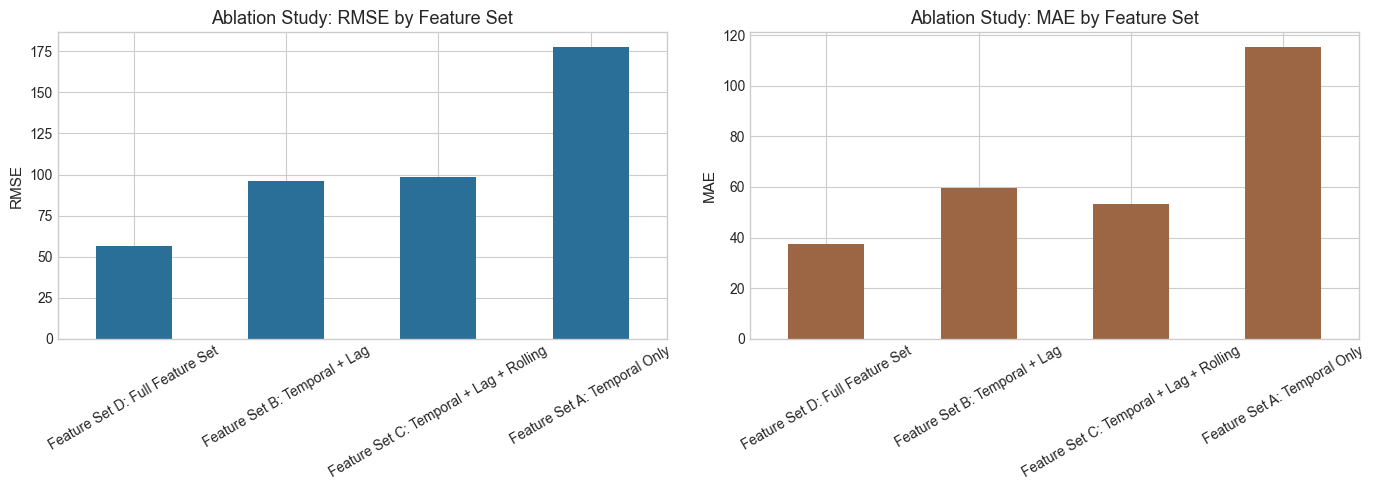

In [8]:
ablation_results = []
for feature_set_name, columns in feature_sets.items():
    ablation_pipeline = build_random_forest_pipeline()
    ablation_pipeline.fit(train_df[columns], train_df["target_next_hour_volume"])
    predictions = ablation_pipeline.predict(test_df[columns])
    metrics = compute_metrics(test_df["target_next_hour_volume"], predictions)
    ablation_results.append({"model_name": "Random Forest", "feature_set": feature_set_name, "RMSE": metrics["RMSE"], "MAE": metrics["MAE"]})
ablation_results_df = pd.DataFrame(ablation_results).sort_values("RMSE").reset_index(drop=True)
ablation_results_df.to_csv(ABLATION_RESULTS_PATH, index=False)
display(ablation_results_df)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ablation_results_df.plot.bar(x="feature_set", y="RMSE", ax=axes[0], color="#2a6f97", legend=False)
ablation_results_df.plot.bar(x="feature_set", y="MAE", ax=axes[1], color="#9c6644", legend=False)
axes[0].set_title("Ablation Study: RMSE by Feature Set")
axes[1].set_title("Ablation Study: MAE by Feature Set")
axes[0].set_ylabel("RMSE")
axes[1].set_ylabel("MAE")
for axis in axes:
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [9]:
best_ablation = ablation_results_df.iloc[0]
ablation_interpretation = f"""
**Ablation Study Interpretation**

- The best-performing feature group is **{best_ablation['feature_set']}** with RMSE = **{best_ablation['RMSE']:.2f}** and MAE = **{best_ablation['MAE']:.2f}**.
- The transition from temporal-only predictors to lag-based predictors shows that immediate traffic history is essential for next-hour demand forecasting.
- Adding rolling statistics further improves performance by summarizing short-term traffic context and volatility.
- The full feature set performs best, indicating that cyclical time variables and engineered demand/signal features contribute useful operational context beyond simple temporal markers.
"""
display(Markdown(ablation_interpretation))



**Ablation Study Interpretation**

- The best-performing feature group is **Feature Set D: Full Feature Set** with RMSE = **56.68** and MAE = **37.47**.
- The transition from temporal-only predictors to lag-based predictors shows that immediate traffic history is essential for next-hour demand forecasting.
- Adding rolling statistics further improves performance by summarizing short-term traffic context and volatility.
- The full feature set performs best, indicating that cyclical time variables and engineered demand/signal features contribute useful operational context beyond simple temporal markers.


## 12. Sequence Modeling Pipeline

The sequence models share a common preparation pipeline based on 24-hour input windows, MinMax scaling, and a chronological validation split taken from the training period only. This keeps the recurrent and convolutional models directly comparable.


In [10]:
# Define the shared sequence configuration for all deep learning models.
sequence_length = 24
sequence_feature_columns = ["hourly_volume", "hour_of_day", "day_of_week", "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos", "is_weekend"]
train_sequence_records = []
test_sequence_records = []
sequence_train_source_indices = []
sequence_test_source_indices = []

# Build leakage-aware rolling windows within each traffic-count location.
for location_id, group in model_df.groupby("location_id"):
    group = group.sort_values("hour").reset_index()
    contiguous = group["hour"].diff().dt.total_seconds().div(3600).fillna(1).eq(1)
    values = group[sequence_feature_columns].to_numpy(dtype=float)
    target_values = group["hourly_volume"].to_numpy(dtype=float)
    years = group["year"].to_numpy(dtype=int)

    # Extract typed arrays once so downstream indexing is explicit and type-safe.
    source_index_values = group["index"].to_numpy(dtype=int)
    timestamp_values = group["hour"].to_numpy()
    location_values = group["location_id"].astype(str).to_numpy()
    signal_values = pd.to_numeric(group["nearest_signal_id"], errors="coerce").to_numpy(dtype=float)

    for end in range(sequence_length - 1, len(group) - 1):
        if not contiguous.iloc[end - sequence_length + 2 : end + 2].all():
            continue

        record = {
            "X": values[end - sequence_length + 1 : end + 1],
            "y": float(target_values[end + 1]),
            "forecast_timestamp": timestamp_values[end + 1],
            "location_id": location_values[end],
            "nearest_signal_id": signal_values[end],
            "source_index": int(source_index_values[end]),
        }

        if years[end + 1] <= 2018:
            train_sequence_records.append(record)
            sequence_train_source_indices.append(record["source_index"])
        elif years[end + 1] == 2019:
            test_sequence_records.append(record)
            sequence_test_source_indices.append(record["source_index"])

# Preserve chronology before carving out the validation segment.
train_sequence_records = sorted(train_sequence_records, key=lambda item: (item["forecast_timestamp"], item["location_id"]))
test_sequence_records = sorted(test_sequence_records, key=lambda item: (item["forecast_timestamp"], item["location_id"]))
X_train_all = np.asarray([record["X"] for record in train_sequence_records], dtype=float)
y_train_all = np.asarray([record["y"] for record in train_sequence_records], dtype=float).reshape(-1, 1)
X_test_sequences = np.asarray([record["X"] for record in test_sequence_records], dtype=float)
y_test_sequences = np.asarray([record["y"] for record in test_sequence_records], dtype=float).reshape(-1, 1)

validation_size = int(np.ceil(0.2 * len(X_train_all)))
train_cutoff = len(X_train_all) - validation_size
X_train_sequences = X_train_all[:train_cutoff]
y_train_sequences = y_train_all[:train_cutoff]
X_validation_sequences = X_train_all[train_cutoff:]
y_validation_sequences = y_train_all[train_cutoff:]

# Apply MinMax scaling consistently across the shared sequence pipeline.
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
X_train_sequences_scaled = feature_scaler.fit_transform(X_train_sequences.reshape(-1, X_train_sequences.shape[-1])).reshape(X_train_sequences.shape)
X_validation_sequences_scaled = feature_scaler.transform(X_validation_sequences.reshape(-1, X_validation_sequences.shape[-1])).reshape(X_validation_sequences.shape)
X_test_sequences_scaled = feature_scaler.transform(X_test_sequences.reshape(-1, X_test_sequences.shape[-1])).reshape(X_test_sequences.shape)
y_train_sequences_scaled = target_scaler.fit_transform(y_train_sequences)
y_validation_sequences_scaled = target_scaler.transform(y_validation_sequences)

sequence_test_index_df = pd.DataFrame(test_sequence_records).drop(columns=["X", "y"]).copy()
sequence_test_index_df["actual_volume"] = y_test_sequences.ravel()
print("Training sequences:", X_train_sequences.shape)
print("Validation sequences:", X_validation_sequences.shape)
print("Test sequences:", X_test_sequences.shape)
display(sequence_test_index_df.head())


Training sequences: (3494, 24, 8)
Validation sequences: (874, 24, 8)
Test sequences: (4800, 24, 8)


,forecast_timestamp,location_id,nearest_signal_id,source_index,actual_volume
0,2019-01-13,10154405_WB,8741191.0,551,199.0
1,2019-01-13,1139432_EB,NaN,1655,331.0
2,2019-01-13,1140808_WB,1140808.0,2039,204.0
3,2019-01-13,1140818_WB,1140818.0,2447,85.0
4,2019-01-13,1140855_EB,1140818.0,2783,114.0


In [11]:
def build_recurrent_model(model_type, input_shape):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    recurrent_layer = tf.keras.layers.LSTM if model_type == "LSTM" else tf.keras.layers.GRU
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        recurrent_layer(64),
        tf.keras.layers.Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
    return model


def build_tcn_model(input_shape):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv1D(64, kernel_size=3, dilation_rate=1, padding="causal", activation="relu")(inputs)
    x = tf.keras.layers.Conv1D(64, kernel_size=3, dilation_rate=2, padding="causal", activation="relu")(x)
    x = tf.keras.layers.Conv1D(64, kernel_size=3, dilation_rate=4, padding="causal", activation="relu")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(16, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
    return model


def fit_and_predict_recurrent(model_type):
    model = build_recurrent_model(model_type, (sequence_length, len(sequence_feature_columns)))
    history = model.fit(
        X_train_sequences_scaled,
        y_train_sequences_scaled,
        validation_data=(X_validation_sequences_scaled, y_validation_sequences_scaled),
        epochs=40,
        batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)],
        verbose=0,
    )
    predictions_scaled = model.predict(X_test_sequences_scaled, verbose=0)
    predictions = target_scaler.inverse_transform(predictions_scaled).ravel()
    metrics = compute_metrics(y_test_sequences.ravel(), predictions)
    return model, history, predictions, metrics


def fit_and_predict_tcn():
    model = build_tcn_model((sequence_length, len(sequence_feature_columns)))
    history = model.fit(
        X_train_sequences_scaled,
        y_train_sequences_scaled,
        validation_data=(X_validation_sequences_scaled, y_validation_sequences_scaled),
        epochs=40,
        batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)],
        verbose=0,
    )
    predictions_scaled = model.predict(X_test_sequences_scaled, verbose=0)
    predictions = target_scaler.inverse_transform(predictions_scaled).ravel()
    metrics = compute_metrics(y_test_sequences.ravel(), predictions)
    return model, history, predictions, metrics


## 13. LSTM Forecasting Model

The LSTM model provides a recurrent neural benchmark that can learn ordered temporal dependencies directly from historical traffic sequences.


In [12]:
lstm_model, lstm_history, lstm_predictions, lstm_metrics = fit_and_predict_recurrent("LSTM")
display(pd.DataFrame([{"model_name": "LSTM", "RMSE": lstm_metrics["RMSE"], "MAE": lstm_metrics["MAE"]}]))


E0000 00:00:1773627396.047658  252402 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


,model_name,RMSE,MAE
0,LSTM,56.081842,38.982484


In [13]:
lstm_interpretation = f"""
**LSTM Interpretation**

- The LSTM achieved RMSE = **{lstm_metrics['RMSE']:.2f}** and MAE = **{lstm_metrics['MAE']:.2f}** on the 2019 holdout subset.
- Sequence models are attractive because they can learn temporal dependence directly from ordered observations rather than relying only on manual lag engineering.
- When the tabular pipeline already contains strong engineered lag and rolling features, the LSTM may have a smaller advantage than expected. In this project, it should be interpreted as a complementary sequence benchmark rather than an automatic replacement for the Random Forest baseline.
"""
display(Markdown(lstm_interpretation))



**LSTM Interpretation**

- The LSTM achieved RMSE = **56.08** and MAE = **38.98** on the 2019 holdout subset.
- Sequence models are attractive because they can learn temporal dependence directly from ordered observations rather than relying only on manual lag engineering.
- When the tabular pipeline already contains strong engineered lag and rolling features, the LSTM may have a smaller advantage than expected. In this project, it should be interpreted as a complementary sequence benchmark rather than an automatic replacement for the Random Forest baseline.


## 14. GRU Forecasting Model

The GRU offers a lighter recurrent architecture than the LSTM while still modeling sequential dependence through gated temporal updates.


In [14]:
gru_model, gru_history, gru_predictions, gru_metrics = fit_and_predict_recurrent("GRU")
display(pd.DataFrame([{"model_name": "GRU", "RMSE": gru_metrics["RMSE"], "MAE": gru_metrics["MAE"]}]))


E0000 00:00:1773627405.876797  252402 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


,model_name,RMSE,MAE
0,GRU,55.626711,39.053702


In [15]:
gru_interpretation = f"""
**GRU Interpretation**

- The GRU achieved RMSE = **{gru_metrics['RMSE']:.2f}** and MAE = **{gru_metrics['MAE']:.2f}** on the same 2019 sequence-compatible holdout subset.
- Compared with the LSTM, the GRU provides a lighter recurrent architecture with fewer gating parameters, which can be attractive when training efficiency matters.
- Its results show whether a simpler recurrent model can capture enough daily and weekly demand structure without the additional complexity of an LSTM.
"""
display(Markdown(gru_interpretation))



**GRU Interpretation**

- The GRU achieved RMSE = **55.63** and MAE = **39.05** on the same 2019 sequence-compatible holdout subset.
- Compared with the LSTM, the GRU provides a lighter recurrent architecture with fewer gating parameters, which can be attractive when training efficiency matters.
- Its results show whether a simpler recurrent model can capture enough daily and weekly demand structure without the additional complexity of an LSTM.


## 15. Temporal Convolutional Network (TCN)

The TCN introduces a modern convolution-based sequence model that uses causal 1D filters rather than recurrent memory. This broadens the forecasting comparison beyond recurrent neural networks.


In [16]:
tcn_model, tcn_history, tcn_predictions, tcn_metrics = fit_and_predict_tcn()
display(pd.DataFrame([{"model_name": "TCN", "RMSE": tcn_metrics["RMSE"], "MAE": tcn_metrics["MAE"]}]))


E0000 00:00:1773627416.310947  252402 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


,model_name,RMSE,MAE
0,TCN,66.722222,42.485575


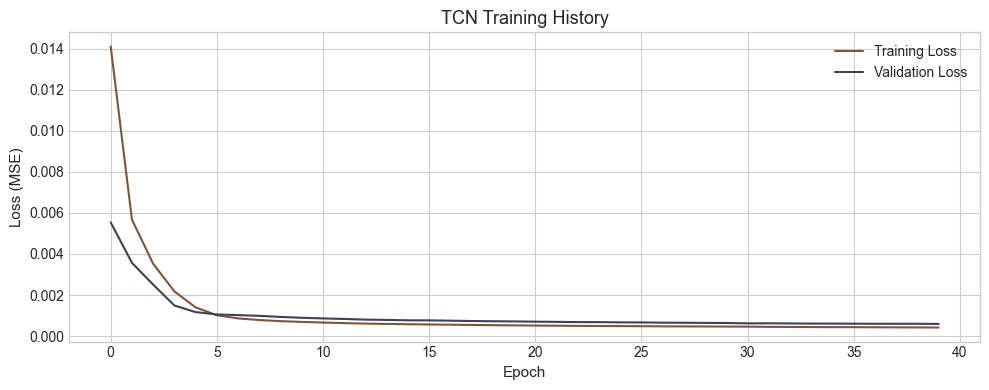

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(tcn_history.history["loss"], label="Training Loss", color="#7f5539")
plt.plot(tcn_history.history["val_loss"], label="Validation Loss", color="#3d405b")
plt.title("TCN Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
tcn_interpretation = f"""
**TCN Interpretation**

- The TCN achieved RMSE = **{tcn_metrics['RMSE']:.2f}** and MAE = **{tcn_metrics['MAE']:.2f}** on the 2019 holdout subset.
- The model captures short-term temporal structure using causal convolutions instead of recurrent memory, which makes it a useful modern comparator for traffic forecasting.
- TCNs can perform well when traffic demand contains repeated local temporal patterns, but the comparison with LSTM and GRU should focus on whether convolutional sequence modeling captures demand dynamics more effectively than recurrent architectures in this dataset.
"""
display(Markdown(tcn_interpretation))



**TCN Interpretation**

- The TCN achieved RMSE = **66.72** and MAE = **42.49** on the 2019 holdout subset.
- The model captures short-term temporal structure using causal convolutions instead of recurrent memory, which makes it a useful modern comparator for traffic forecasting.
- TCNs can perform well when traffic demand contains repeated local temporal patterns, but the comparison with LSTM and GRU should focus on whether convolutional sequence modeling captures demand dynamics more effectively than recurrent architectures in this dataset.


## 16. Final Model Comparison

The final comparison places the Random Forest baseline alongside the LSTM, GRU, and TCN on the same sequence-compatible 2019 holdout subset using RMSE and MAE.


,model_name,RMSE,MAE
0,Random Forest,55.292001,36.901536
1,GRU,55.626711,39.053702
2,LSTM,56.081842,38.982484
3,TCN,66.722222,42.485575


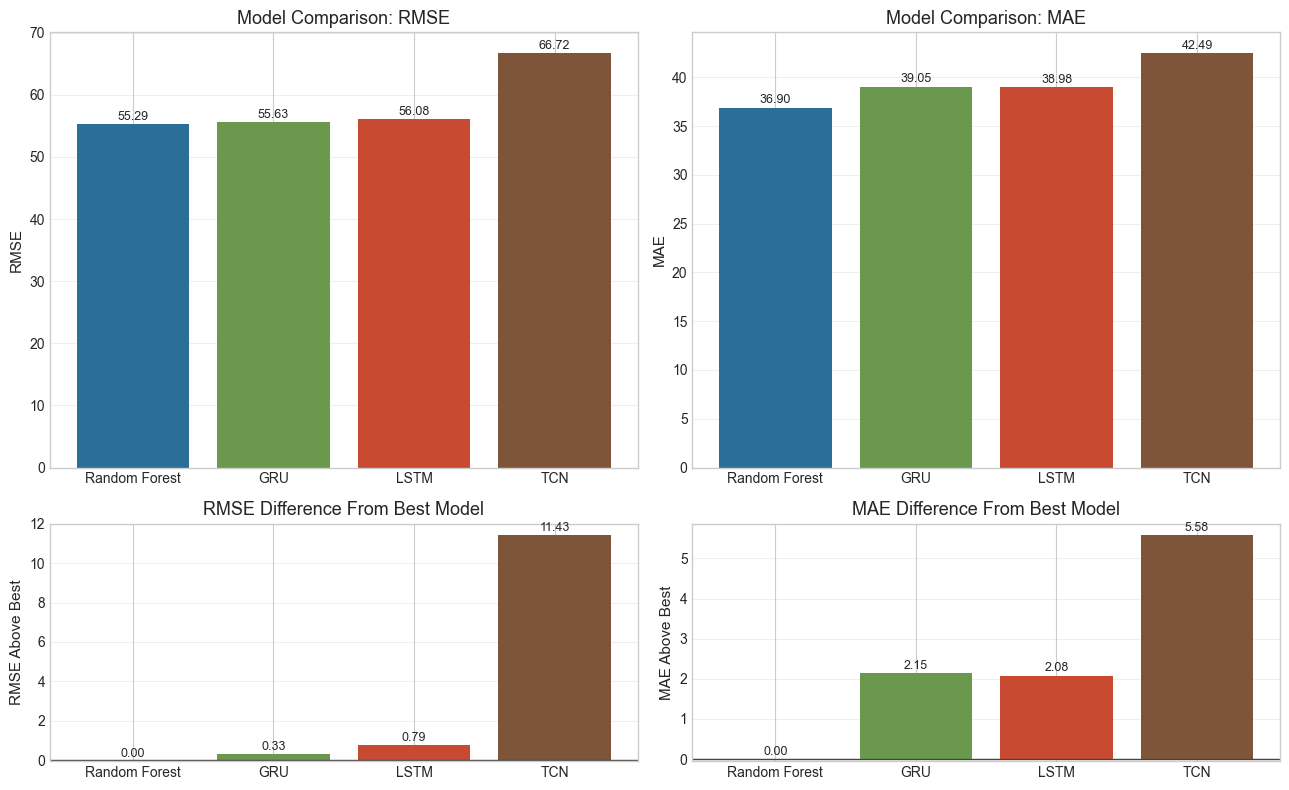

In [19]:
sequence_source_indices = sorted(set(sequence_train_source_indices) | set(sequence_test_source_indices))
sequence_compatible_df = model_df.loc[sequence_source_indices].copy()
sequence_compatible_df = sequence_compatible_df.sort_values(["forecast_timestamp", "location_id"]).reset_index(drop=True)
sequence_train_df = sequence_compatible_df[sequence_compatible_df["year"].between(2015, 2018)].copy()
sequence_test_df = sequence_compatible_df[sequence_compatible_df["year"] == 2019].copy()

rf_sequence_pipeline = build_random_forest_pipeline()
rf_sequence_pipeline.fit(sequence_train_df[rf_full_features], sequence_train_df["target_next_hour_volume"])
rf_sequence_predictions = rf_sequence_pipeline.predict(sequence_test_df[rf_full_features])
rf_sequence_metrics = compute_metrics(sequence_test_df["target_next_hour_volume"], rf_sequence_predictions)

model_results_df = pd.DataFrame([
    {"model_name": "Random Forest", "RMSE": rf_sequence_metrics["RMSE"], "MAE": rf_sequence_metrics["MAE"]},
    {"model_name": "LSTM", "RMSE": lstm_metrics["RMSE"], "MAE": lstm_metrics["MAE"]},
    {"model_name": "GRU", "RMSE": gru_metrics["RMSE"], "MAE": gru_metrics["MAE"]},
    {"model_name": "TCN", "RMSE": tcn_metrics["RMSE"], "MAE": tcn_metrics["MAE"]},
]).sort_values("RMSE").reset_index(drop=True)
model_results_df.to_csv(MODEL_RESULTS_PATH, index=False)
display(model_results_df)

bar_colors = ("#2a6f97", "#6a994e", "#c84b31", "#7f5539")
labels = model_results_df["model_name"].astype(str).tolist()
x = np.arange(len(labels), dtype=float)

best_rmse = model_results_df["RMSE"].min()
best_mae = model_results_df["MAE"].min()
comparison_delta_df = model_results_df.copy()
comparison_delta_df["RMSE_above_best"] = comparison_delta_df["RMSE"] - best_rmse
comparison_delta_df["MAE_above_best"] = comparison_delta_df["MAE"] - best_mae

fig, axes = plt.subplots(2, 2, figsize=(13, 8), height_ratios=[2.2, 1.2])

axes[0, 0].bar(x, model_results_df["RMSE"].to_numpy(dtype=float), color=bar_colors)
axes[0, 1].bar(x, model_results_df["MAE"].to_numpy(dtype=float), color=bar_colors)
axes[1, 0].bar(x, comparison_delta_df["RMSE_above_best"].to_numpy(dtype=float), color=bar_colors)
axes[1, 1].bar(x, comparison_delta_df["MAE_above_best"].to_numpy(dtype=float), color=bar_colors)

axes[0, 0].set_title("Model Comparison: RMSE")
axes[0, 1].set_title("Model Comparison: MAE")
axes[1, 0].set_title("RMSE Difference From Best Model")
axes[1, 1].set_title("MAE Difference From Best Model")

axes[0, 0].set_ylabel("RMSE")
axes[0, 1].set_ylabel("MAE")
axes[1, 0].set_ylabel("RMSE Above Best")
axes[1, 1].set_ylabel("MAE Above Best")

for axis in axes.flat:
    axis.set_xticks(x)
    axis.set_xticklabels(labels)
    axis.set_xlabel("")
    axis.grid(axis="y", alpha=0.3)

# The lower row magnifies small model gaps so close performance is visible.
for axis, metric in zip(axes[0], ["RMSE", "MAE"]):
    values = model_results_df[metric].to_numpy(dtype=float)
    for xpos, value in zip(x, values):
        axis.text(xpos, value + 0.15, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

for axis, metric in zip(axes[1], ["RMSE_above_best", "MAE_above_best"]):
    values = comparison_delta_df[metric].to_numpy(dtype=float)
    axis.axhline(0, color="#444444", linewidth=1)
    axis.set_ylim(bottom=-0.05)
    for xpos, value in zip(x, values):
        axis.text(xpos, value + 0.03, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [20]:
best_model_row = model_results_df.iloc[0]
comparison_interpretation = f"""
**Final Model Comparison Interpretation**

- On the aligned 2019 holdout subset, the best-performing model is **{best_model_row['model_name']}** with RMSE = **{best_model_row['RMSE']:.2f}** and MAE = **{best_model_row['MAE']:.2f}**.
- The TCN result should be interpreted relative to both recurrent models: if it trails the LSTM and GRU, that suggests local convolutional pattern extraction is less effective here than the combination of recurrent sequence learning and strong tabular engineering.
- If the Random Forest remains strongest, that indicates that engineered lag, rolling, and operational predictors still provide a highly competitive forecasting representation for this traffic dataset.
- The convolutional temporal approach remains valuable academically because it broadens the forecasting comparison beyond recurrent networks and tests whether short-range temporal structure alone is sufficient for accurate next-hour demand prediction.
"""
display(Markdown(comparison_interpretation))



**Final Model Comparison Interpretation**

- On the aligned 2019 holdout subset, the best-performing model is **Random Forest** with RMSE = **55.29** and MAE = **36.90**.
- The TCN result should be interpreted relative to both recurrent models: if it trails the LSTM and GRU, that suggests local convolutional pattern extraction is less effective here than the combination of recurrent sequence learning and strong tabular engineering.
- If the Random Forest remains strongest, that indicates that engineered lag, rolling, and operational predictors still provide a highly competitive forecasting representation for this traffic dataset.
- The convolutional temporal approach remains valuable academically because it broadens the forecasting comparison beyond recurrent networks and tests whether short-range temporal structure alone is sufficient for accurate next-hour demand prediction.


## 17. Forecast Visualization

The forecast plots complement the error tables by showing how closely the competing models track the observed next-hour demand profile over time.


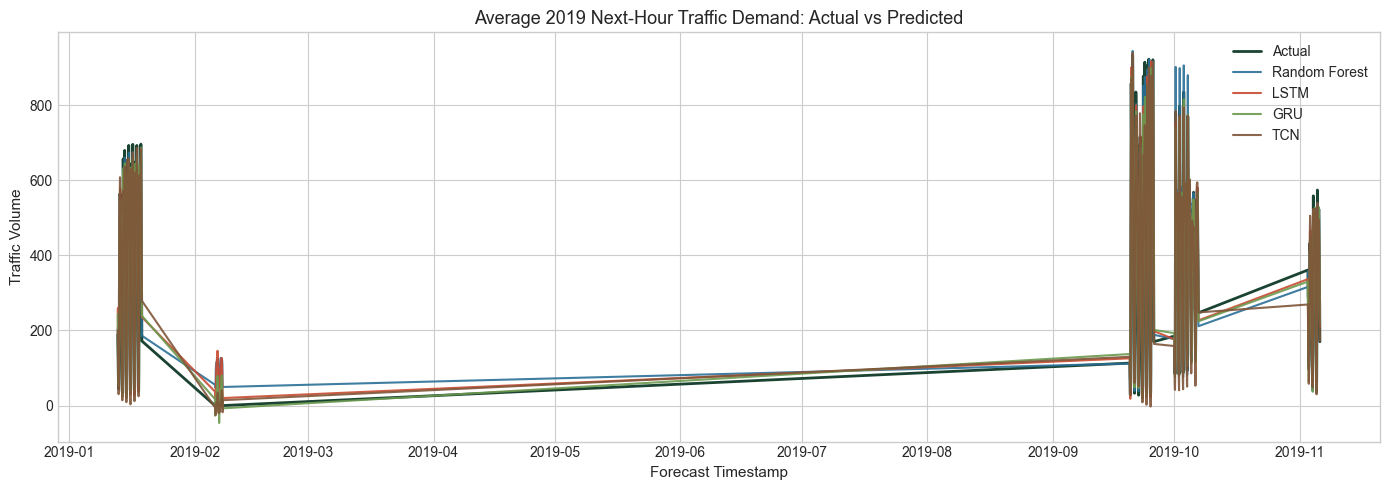

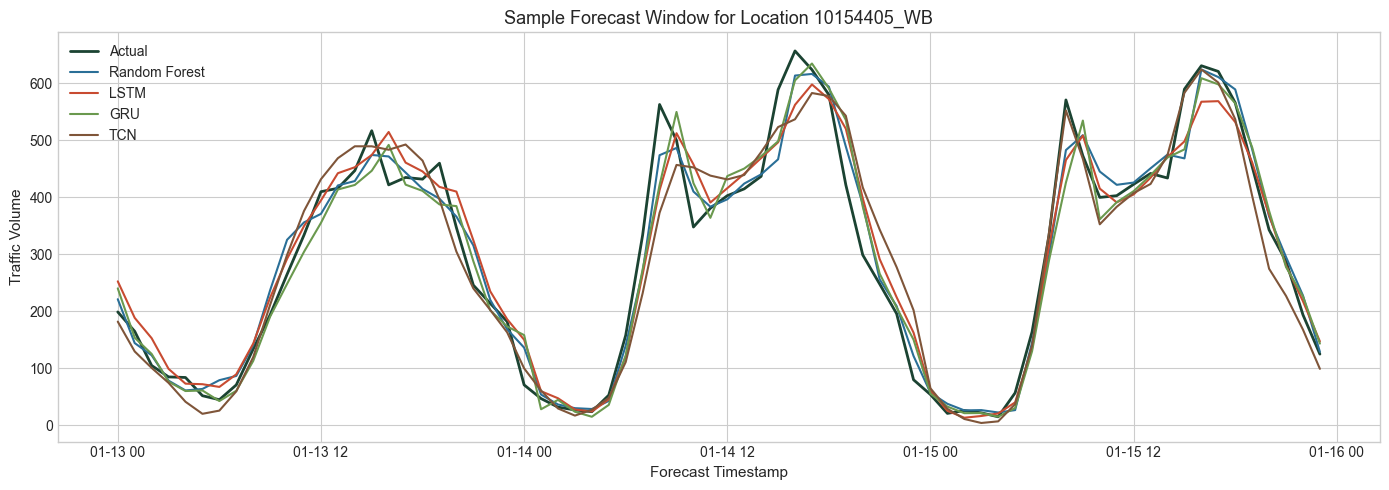

In [21]:
rf_predictions_df = sequence_test_df[["location_id", "nearest_signal_id", "forecast_timestamp", "target_next_hour_volume"]].copy()
rf_predictions_df = rf_predictions_df.rename(columns={"target_next_hour_volume": "actual_volume"})
rf_predictions_df["predicted_volume"] = pd.Series(np.asarray(rf_sequence_predictions, dtype=float).ravel(), index=rf_predictions_df.index)
rf_predictions_df["model_name"] = "Random Forest"

lstm_predictions_df = sequence_test_index_df[["location_id", "nearest_signal_id", "forecast_timestamp", "actual_volume"]].copy()
lstm_predictions_df["predicted_volume"] = pd.Series(np.asarray(lstm_predictions, dtype=float).ravel(), index=lstm_predictions_df.index)
lstm_predictions_df["model_name"] = "LSTM"

gru_predictions_df = sequence_test_index_df[["location_id", "nearest_signal_id", "forecast_timestamp", "actual_volume"]].copy()
gru_predictions_df["predicted_volume"] = pd.Series(np.asarray(gru_predictions, dtype=float).ravel(), index=gru_predictions_df.index)
gru_predictions_df["model_name"] = "GRU"

tcn_predictions_df = sequence_test_index_df[["location_id", "nearest_signal_id", "forecast_timestamp", "actual_volume"]].copy()
tcn_predictions_df["predicted_volume"] = pd.Series(np.asarray(tcn_predictions, dtype=float).ravel(), index=tcn_predictions_df.index)
tcn_predictions_df["model_name"] = "TCN"

forecast_output_df = pd.concat([rf_predictions_df, lstm_predictions_df, gru_predictions_df, tcn_predictions_df], ignore_index=True).sort_values(["model_name", "forecast_timestamp", "location_id"])
forecast_output_df.to_csv(FORECAST_OUTPUT_PATH, index=False)

actual_series = rf_predictions_df.groupby("forecast_timestamp", as_index=False)["actual_volume"].mean()
rf_series = rf_predictions_df.groupby("forecast_timestamp", as_index=False)["predicted_volume"].mean()
lstm_series = lstm_predictions_df.groupby("forecast_timestamp", as_index=False)["predicted_volume"].mean()
gru_series = gru_predictions_df.groupby("forecast_timestamp", as_index=False)["predicted_volume"].mean()
tcn_series = tcn_predictions_df.groupby("forecast_timestamp", as_index=False)["predicted_volume"].mean()

plt.figure(figsize=(14, 5))
plt.plot(actual_series["forecast_timestamp"], actual_series["actual_volume"], label="Actual", linewidth=2, color="#1b4332")
plt.plot(rf_series["forecast_timestamp"], rf_series["predicted_volume"], label="Random Forest", color="#2a6f97", alpha=0.9)
plt.plot(lstm_series["forecast_timestamp"], lstm_series["predicted_volume"], label="LSTM", color="#c84b31", alpha=0.9)
plt.plot(gru_series["forecast_timestamp"], gru_series["predicted_volume"], label="GRU", color="#6a994e", alpha=0.9)
plt.plot(tcn_series["forecast_timestamp"], tcn_series["predicted_volume"], label="TCN", color="#7f5539", alpha=0.9)
plt.title("Average 2019 Next-Hour Traffic Demand: Actual vs Predicted")
plt.xlabel("Forecast Timestamp")
plt.ylabel("Traffic Volume")
plt.legend()
plt.tight_layout()
plt.show()

sample_location = rf_predictions_df["location_id"].mode().iloc[0]
sample_actual = rf_predictions_df.loc[rf_predictions_df["location_id"] == sample_location].sort_values("forecast_timestamp").head(72)
sample_lstm = lstm_predictions_df.loc[lstm_predictions_df["location_id"] == sample_location].sort_values("forecast_timestamp").head(72)
sample_gru = gru_predictions_df.loc[gru_predictions_df["location_id"] == sample_location].sort_values("forecast_timestamp").head(72)
sample_tcn = tcn_predictions_df.loc[tcn_predictions_df["location_id"] == sample_location].sort_values("forecast_timestamp").head(72)

plt.figure(figsize=(14, 5))
plt.plot(sample_actual["forecast_timestamp"], sample_actual["actual_volume"], label="Actual", linewidth=2, color="#1b4332")
plt.plot(sample_actual["forecast_timestamp"], sample_actual["predicted_volume"], label="Random Forest", color="#2a6f97")
plt.plot(sample_lstm["forecast_timestamp"], sample_lstm["predicted_volume"], label="LSTM", color="#c84b31")
plt.plot(sample_gru["forecast_timestamp"], sample_gru["predicted_volume"], label="GRU", color="#6a994e")
plt.plot(sample_tcn["forecast_timestamp"], sample_tcn["predicted_volume"], label="TCN", color="#7f5539")
plt.title(f"Sample Forecast Window for Location {sample_location}")
plt.xlabel("Forecast Timestamp")
plt.ylabel("Traffic Volume")
plt.legend()
plt.tight_layout()
plt.show()


## 18. Export Forecast Outputs

The notebook writes model predictions and summary result tables to the processed data directory so they can be reused in the later optimization and simulation stages.


In [22]:
display(pd.DataFrame({
    "file": [
        str(FORECAST_OUTPUT_PATH.relative_to(PROJECT_ROOT)),
        str(MODEL_RESULTS_PATH.relative_to(PROJECT_ROOT)),
        str(ABLATION_RESULTS_PATH.relative_to(PROJECT_ROOT)),
    ],
    "rows": [len(forecast_output_df), len(model_results_df), len(ablation_results_df)],
}))


,file,rows
0,data/processed/traffic_demand_forecasts.csv,19200
1,data/processed/forecast_model_results.csv,4
2,data/processed/forecast_ablation_results.csv,4


## 19. Final Conclusion

The conclusion synthesizes model performance, feature-importance insights from the ablation study, and the practical role of forecast outputs in the downstream capstone workflow.


In [23]:
best_model = model_results_df.iloc[0]
best_ablation = ablation_results_df.iloc[0]
conclusion = f"""
**Forecasting Summary**

- The notebook used `signal_optimization_features_2015_2019.csv` as the primary dataset and forecasted **next-hour traffic volume**.
- Random Forest remained the **tabular baseline**, while **LSTM**, **GRU**, and **TCN** served as sequence-based deep learning comparators using 24-hour historical demand windows.
- The best final model on the aligned 2019 holdout subset was **{best_model['model_name']}** with RMSE = **{best_model['RMSE']:.2f}** and MAE = **{best_model['MAE']:.2f}**.
- The ablation study showed that **{best_ablation['feature_set']}** provided the strongest Random Forest performance, confirming the importance of lag history, rolling summaries, and the broader engineered traffic/signal context.
- Cyclical time features made the daily and weekly traffic structure explicit in the feature space, which improved the interpretability of the forecasting design even when the tabular benchmark remained highly competitive.
- The TCN result indicates whether convolutional sequence modeling alone can capture traffic demand effectively; in this notebook it should be interpreted relative to the recurrent models and the Random Forest benchmark.
- The updated forecast outputs in `traffic_demand_forecasts.csv` provide the forward-looking demand inputs that will be used in later timing optimization and traffic simulation stages.
"""
display(Markdown(conclusion))



**Forecasting Summary**

- The notebook used `signal_optimization_features_2015_2019.csv` as the primary dataset and forecasted **next-hour traffic volume**.
- Random Forest remained the **tabular baseline**, while **LSTM**, **GRU**, and **TCN** served as sequence-based deep learning comparators using 24-hour historical demand windows.
- The best final model on the aligned 2019 holdout subset was **Random Forest** with RMSE = **55.29** and MAE = **36.90**.
- The ablation study showed that **Feature Set D: Full Feature Set** provided the strongest Random Forest performance, confirming the importance of lag history, rolling summaries, and the broader engineered traffic/signal context.
- Cyclical time features made the daily and weekly traffic structure explicit in the feature space, which improved the interpretability of the forecasting design even when the tabular benchmark remained highly competitive.
- The TCN result indicates whether convolutional sequence modeling alone can capture traffic demand effectively; in this notebook it should be interpreted relative to the recurrent models and the Random Forest benchmark.
- The updated forecast outputs in `traffic_demand_forecasts.csv` provide the forward-looking demand inputs that will be used in later timing optimization and traffic simulation stages.
